<a href="https://colab.research.google.com/github/simrankhan-coder/Face-Mask-Detection/blob/main/mask_detection_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Mask Detection — Improved (Transfer Learning + MobileNetV2)




In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_score, recall_score, f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 1. Load file paths (not raw pixels yet)



In [3]:
directory = os.path.join(path, "data")
categories = ['with_mask', 'without_mask']   # label 0 = with_mask, label 1 = without_mask

filepaths, labels = [], []
for category in categories:
    label = categories.index(category)
    folder = os.path.join(directory, category)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        # quick sanity check that the file is actually readable as an image
        if os.path.isfile(img_path):
            filepaths.append(img_path)
            labels.append(label)

filepaths = np.array(filepaths)
labels = np.array(labels)

print(f"Total images: {len(filepaths)}")
for category in categories:
    label = categories.index(category)
    print(f"  {category}: {(labels == label).sum()}")


Total images: 7553
  with_mask: 3725
  without_mask: 3828


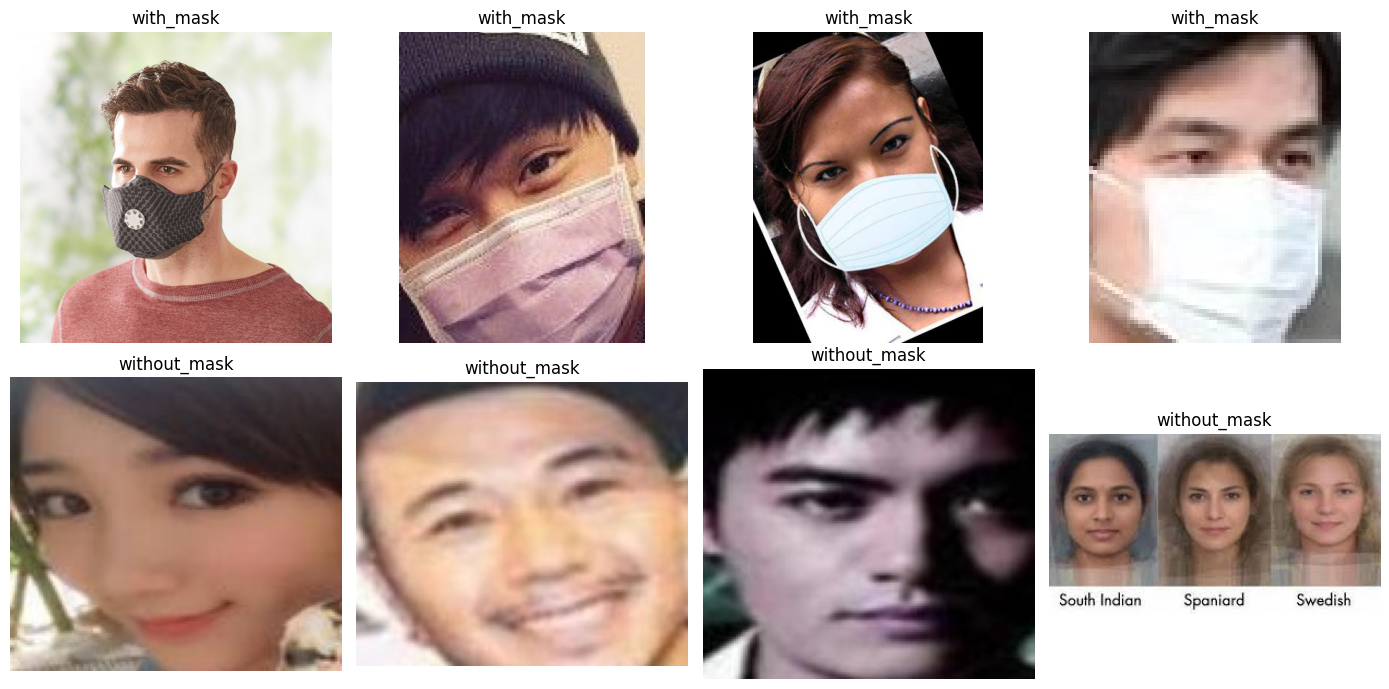

In [4]:
# Visualize a few samples from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, category in enumerate(categories):
    label = categories.index(category)
    idxs = np.where(labels == label)[0]
    sample_idxs = np.random.choice(idxs, 4, replace=False)
    for col, idx in enumerate(sample_idxs):
        img = cv2.cvtColor(cv2.imread(filepaths[idx]), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(category)
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()


## 2. Train / validation / test split



In [5]:
IMAGE_SIZE = 128   # MobileNetV2 works best at >= 96px;
BATCH_SIZE = 32

x_train_paths, x_temp_paths, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.30, random_state=SEED, stratify=labels
)
x_val_paths, x_test_paths, y_val, y_test = train_test_split(
    x_temp_paths, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(x_train_paths)}  Val: {len(x_val_paths)}  Test: {len(x_test_paths)}")


Train: 5287  Val: 1133  Test: 1133


In [6]:
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0140007671653242), 1: np.float64(0.9863805970149254)}


## 3. `tf.data` input pipeline with on-the-fly augmentation

Augmentation is applied **only** to the training set. Validation/test data is only resized and
preprocessed, so evaluation numbers reflect real performance rather than augmented inputs.

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="augmentation")


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    return image, label


def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2048, seed=SEED)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(x_train_paths, y_train, training=True)
val_ds = make_dataset(x_val_paths, y_val, training=False)
test_ds = make_dataset(x_test_paths, y_test, training=False)


## 4. Model: MobileNetV2 backbone + custom head


In [8]:
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze for phase 1

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)   # binary -> single sigmoid unit

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)
checkpoint = ModelCheckpoint('mask_detector_best.keras', monitor='val_loss',
                              save_best_only=True, verbose=1)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce, checkpoint]
)


Epoch 1/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9239 - loss: 0.1708 - precision: 0.9267 - recall: 0.9131
Epoch 1: val_loss improved from None to 0.02716, saving model to mask_detector_best.keras

Epoch 1: finished saving model to mask_detector_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 90s 383ms/step - accuracy: 0.9559 - loss: 0.1108 - precision: 0.9598 - recall: 0.9530 - val_accuracy: 0.9929 - val_loss: 0.0272 - val_precision: 0.9982 - val_recall: 0.9878 - learning_rate: 0.0010
Epoch 2/15
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9745 - loss: 0.0787 - precision: 0.9803 - recall: 0.9701
Epoch 2: val_loss did not improve from 0.02716
166/166 ━━━━━━━━━━━━━━━━━━━━ 31s 170ms/step - accuracy: 0.9781 - loss: 0.0682 - precision: 0.9805 - recall: 0.9761 - val_accuracy: 0.9912 - val_loss: 0.0290 - val_precision: 0.9947 - val_recall: 0.9878 - learning_rate: 0.0010
Epoch 3/15
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9791 - loss: 0.0692 - precision: 

## 5. Fine-tuning

Unfreeze the top layers of the MobileNetV2 backbone and continue training at a much lower
learning rate, so the pretrained low-level features are preserved while higher-level features
adapt to masked/unmasked faces specifically. This step is what typically gives the biggest
accuracy jump over a frozen-backbone or from-scratch model.

In [10]:
base_model.trainable = True

# Freeze all but the last ~30 layers so we fine-tune high-level features only
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # much lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

early_stop_ft = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_reduce_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)
checkpoint_ft = ModelCheckpoint('mask_detector_best.keras', monitor='val_loss',
                                 save_best_only=True, verbose=1)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop_ft, lr_reduce_ft, checkpoint_ft]
)


Epoch 1/15
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9338 - loss: 0.1758 - precision: 0.9684 - recall: 0.8962
Epoch 1: val_loss improved from None to 0.02157, saving model to mask_detector_best.keras

Epoch 1: finished saving model to mask_detector_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 67s 269ms/step - accuracy: 0.9480 - loss: 0.1372 - precision: 0.9721 - recall: 0.9239 - val_accuracy: 0.9903 - val_loss: 0.0216 - val_precision: 0.9896 - val_recall: 0.9913 - learning_rate: 1.0000e-05
Epoch 2/15
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9639 - loss: 0.0816 - precision: 0.9728 - recall: 0.9561
Epoch 2: val_loss improved from 0.02157 to 0.02150, saving model to mask_detector_best.keras

Epoch 2: finished saving model to mask_detector_best.keras
166/166 ━━━━━━━━━━━━━━━━━━━━ 33s 178ms/step - accuracy: 0.9690 - loss: 0.0764 - precision: 0.9747 - recall: 0.9638 - val_accuracy: 0.9912 - val_loss: 0.0215 - val_precision: 0.9896 - val_recall: 0.9930 - learning_rate

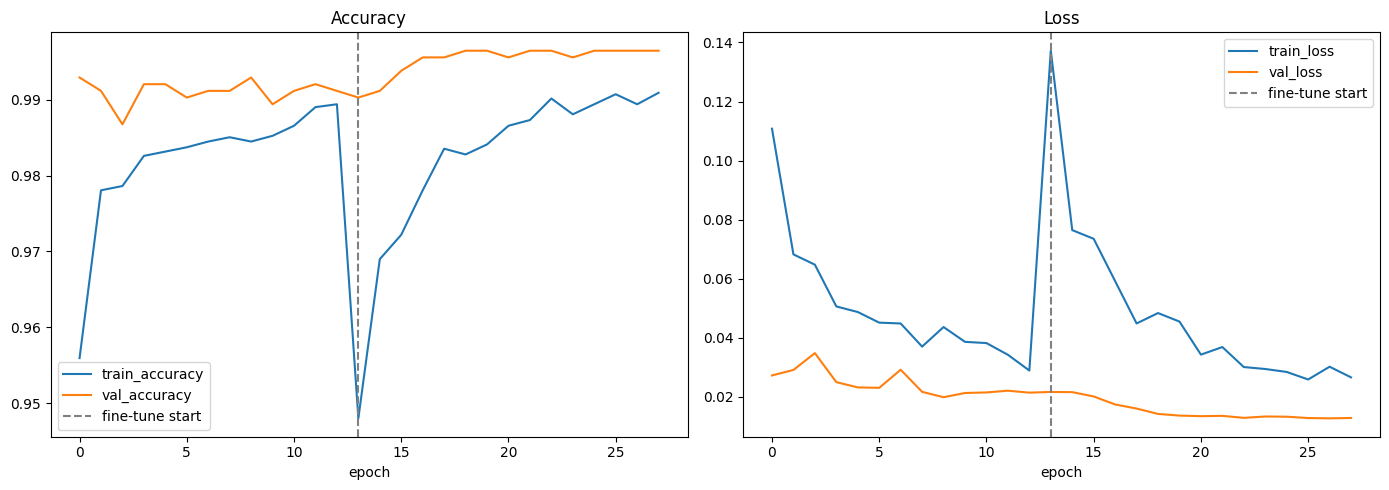

In [11]:
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine_history(history_head, history_finetune, 'accuracy')
val_acc = combine_history(history_head, history_finetune, 'val_accuracy')
loss = combine_history(history_head, history_finetune, 'loss')
val_loss = combine_history(history_head, history_finetune, 'val_loss')
switch_epoch = len(history_head.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(acc, label='train_accuracy')
axes[0].plot(val_acc, label='val_accuracy')
axes[0].axvline(switch_epoch, color='gray', linestyle='--', label='fine-tune start')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(loss, label='train_loss')
axes[1].plot(val_loss, label='val_loss')
axes[1].axvline(switch_epoch, color='gray', linestyle='--', label='fine-tune start')
axes[1].set_title('Loss'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Full evaluation on the held-out test set



In [12]:
best_model = tf.keras.models.load_model('mask_detector_best.keras')

test_probs = best_model.predict(test_ds).ravel()
y_pred = (test_probs >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=categories, digits=4))

print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")


36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 236ms/step
              precision    recall  f1-score   support

   with_mask     0.9892    0.9875    0.9884       559
without_mask     0.9878    0.9895    0.9887       574

    accuracy                         0.9885      1133
   macro avg     0.9885    0.9885    0.9885      1133
weighted avg     0.9885    0.9885    0.9885      1133

Precision: 0.9878
Recall:    0.9895
F1-score:  0.9887


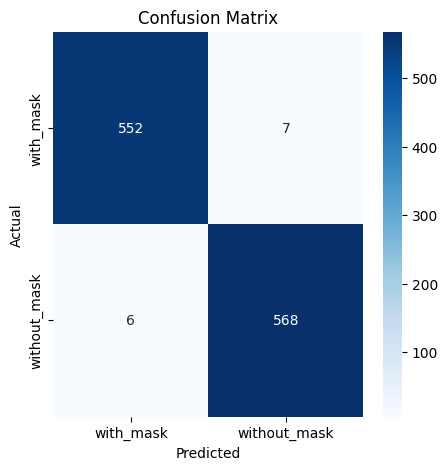

In [13]:
plt.figure(figsize=(5, 5))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


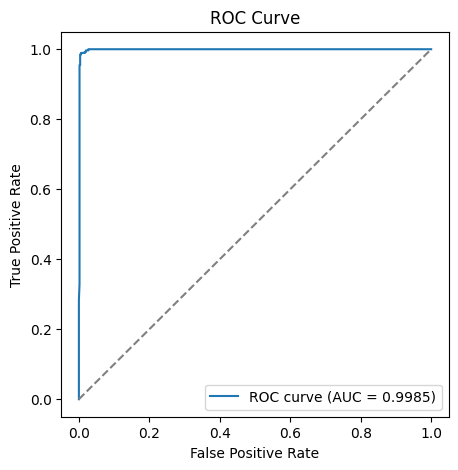

In [14]:
fpr, tpr, _ = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [15]:
best_model.save("mask_detector_final.keras")
print("✅ Final model saved as mask_detector_final.keras")


✅ Final model saved as mask_detector_final.keras


## 7. Inference function


In [16]:
def detect_mask(image_path, model=None, threshold=0.5):
    model = model or best_model
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = preprocess_input(image.astype('float32'))
    prob = model.predict(np.expand_dims(image, axis=0), verbose=0)[0][0]

    predicted_class = categories[1] if prob >= threshold else categories[0]
    confidence = prob if prob >= threshold else 1 - prob
    print(f"{predicted_class}  (confidence: {confidence:.2%})")
    return predicted_class, confidence


In [17]:
sample_mask = x_test_paths[y_test == 0][0]
sample_no_mask = x_test_paths[y_test == 1][0]

detect_mask(sample_mask)
detect_mask(sample_no_mask)


with_mask  (confidence: 100.00%)
without_mask  (confidence: 99.76%)


('without_mask', np.float32(0.9976017))

## 8. Optional: webcam capture (Colab only)



In [20]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


In [ ]:
from IPython.display import Image as IPImage
try:
    filename = take_photo()
    print('Saved to', filename)
    display(IPImage(filename))
    detect_mask(filename)
except Exception as err:
    print(str(err))
